# Zarr with pyramids — basics

pyramids reads and writes **Zarr v3** stores for single rasters (`Dataset`). On disk, the
layout follows the CF / GeoZarr convention so the store opens georeferenced in any
standards-aware reader (rioxarray, odc-geo, `xarray.open_zarr`, GDAL's Zarr driver) without
needing pyramids in the loop.

This notebook is fully offline — it builds small in-memory rasters in a temp folder, so it
runs anywhere with no network or cloud credentials. It walks through:

1. A basic write / read round-trip
2. What the on-disk GeoZarr layout actually looks like
3. Choosing a compression codec
4. Writing multiscale pyramid levels (overviews) and reading them back
5. The `[lazy]` extra requirement


## Setup

Force a non-interactive matplotlib backend (defensive — this notebook does not plot) and
build a temp workspace with a small synthetic raster.

In [1]:

import tempfile
from pathlib import Path

import numpy as np

from pyramids.dataset import Dataset

workspace = Path(tempfile.mkdtemp(prefix="pyramids-zarr-basics-"))
print("workspace:", workspace)

rows, cols = 32, 48
arr = np.arange(2 * rows * cols, dtype=np.float32).reshape(2, rows, cols)
mem = Dataset.create_from_array(
    arr,
    top_left_corner=(0.0, float(rows)),
    cell_size=1.0,
    epsg=4326,
    no_data_value=-9999.0,
)
mem.band_names = ["red", "nir"]

# `to_zarr` builds a dask graph that reopens the source by path, so round-trip the
# in-memory array through a temp GeoTIFF first — exactly how a real workflow would start.
source_tif = workspace / "source.tif"
mem.to_file(source_tif)
ds = Dataset.read_file(source_tif)
ds.band_names = ["red", "nir"]
ds.shape, ds.cell_size, ds.epsg


2026-05-28 23:30:41 | INFO | pyramids.base.config | Logging is configured.


workspace: C:\Users\main\AppData\Local\Temp\pyramids-zarr-basics-4iq4aq91


((2, 32, 48), 1.0, 4326)

## 1. Round-trip a `Dataset`

`to_zarr` writes the GeoZarr layout (data + `x` / `y` coords + `spatial_ref` grid-mapping
variable) and round-trip metadata (nodata, band names, dtype). `from_zarr` recovers all of
it. Default chunking is parallel-friendly; default compressor is whatever zarr v3 ships.

In [2]:
store = workspace / "basic.zarr"
ds.to_zarr(store)

rt = Dataset.from_zarr(store)

assert rt.shape == ds.shape
assert rt.epsg == ds.epsg
assert rt.cell_size == ds.cell_size
assert rt.band_names == ds.band_names
assert rt.no_data_value[0] == -9999.0
np.testing.assert_array_equal(rt.read_array(), ds.read_array())
print("round-trip OK")

round-trip OK


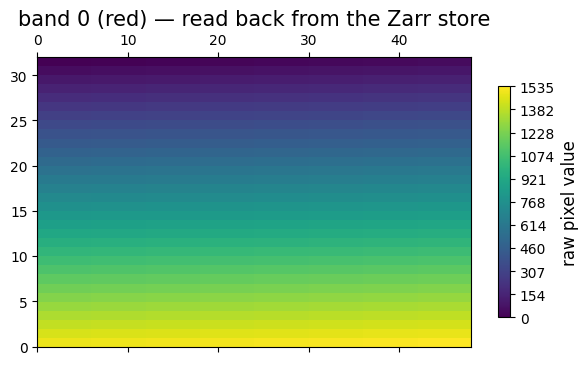

In [3]:
# --- Visual round-trip check ---
# Render the array recovered from the Zarr store via `Dataset.plot()` (pyramids'
# built-in raster renderer, which wraps cleopatra). The round-trip identity itself
# is asserted programmatically in the cell above; this panel just shows what came
# back so you can eyeball the layout.
rt.plot(
    band=0,
    figsize=(7, 4),
    title="band 0 (red) — read back from the Zarr store",
    cbar_label="raw pixel value",
    cmap="viridis",
)


## 2. What's on disk

Open the same store with `zarr` directly to inspect the layout. You'll see four arrays —
`data` (the raster), `x` and `y` (pixel-centre coordinates), and `spatial_ref` (the scalar
grid-mapping variable carrying `crs_wkt` and `GeoTransform`) — plus the CF link
`grid_mapping = "spatial_ref"` on `data`.

In [4]:
import zarr

g = zarr.open_group(str(store), mode="r")

print("arrays   :", sorted(g.array_keys()))
print("data     :", g["data"].shape, g["data"].dtype)
print("x        :", g["x"][:5], "...")
print("y        :", g["y"][:5], "...")
print("grid_map :", g["data"].attrs.get("grid_mapping"))
print("dim_names:", g["data"].attrs.get("_ARRAY_DIMENSIONS"))
print("epsg     :", g["data"].attrs.get("epsg"))
print("crs_wkt? :", "crs_wkt" in dict(g["spatial_ref"].attrs))

arrays   : ['data', 'spatial_ref', 'x', 'y']
data     : (2, 32, 48) float32
x        : [0.5 1.5 2.5 3.5 4.5] ...
y        : [31.5 30.5 29.5 28.5 27.5] ...
grid_map : spatial_ref
dim_names: ['band', 'y', 'x']
epsg     : 4326
crs_wkt? : True


## 3. Choosing a compression codec

`compressor=` is passed through to zarr v3's `create_array(compressors=...)`. Common
choices:

- `"auto"` (default) — let zarr pick its default codec.
- `None` — write **uncompressed** (fast, biggest on disk; useful for benchmarks).
- A v3 codec instance — e.g. `BloscCodec(cname="zstd", clevel=5)`. A bare codec is wrapped
  in a list automatically; you can also pass a list yourself.

Below we write the same payload three ways and compare on-disk size.

In [5]:
from zarr.codecs import BloscCodec

def store_size(p: Path) -> int:
    return sum(f.stat().st_size for f in p.rglob("*") if f.is_file())

for label, kwargs, target in [
    ("default",      {},                                          workspace / "default.zarr"),
    ("uncompressed", {"compressor": None},                         workspace / "raw.zarr"),
    ("zstd-5",       {"compressor": BloscCodec(cname="zstd", clevel=5)}, workspace / "zstd.zarr"),
]:
    ds.to_zarr(target, **kwargs)
    print(f"{label:>13} -> {store_size(target):>8} bytes")

# All three variants still round-trip identically:
for target in (workspace / "default.zarr", workspace / "raw.zarr", workspace / "zstd.zarr"):
    np.testing.assert_array_equal(Dataset.from_zarr(target).read_array(), arr)

      default ->    17797 bytes


 uncompressed ->    22116 bytes
       zstd-5 ->    11643 bytes


## 4. Multiscale pyramid levels

Pass `overview_factors=[2, 4, ...]` to also emit decimated arrays (`data_2`, `data_4`, …)
alongside the full-resolution `data`. pyramids also writes an OGC / OME-Zarr v0.4
`multiscales` block at the root so GDAL's Zarr v3 driver exposes the levels as overviews.

Read a level back with `level=`: cell size scales by the factor.

In [6]:
ms_store = workspace / "pyramid.zarr"
ds.to_zarr(ms_store, overview_factors=[2, 4], overview_resampling="average")

g_ms = zarr.open_group(str(ms_store), mode="r")
print("arrays    :", sorted(g_ms.array_keys()))
print("multiscale:", g_ms.attrs.get("multiscales")[0]["datasets"])

for level in (1, 2, 4):
    lvl = Dataset.from_zarr(ms_store, level=level)
    print(f"shape ({level}) : {lvl.shape}  cell_size: {lvl.cell_size}")


arrays    : ['data', 'data_2', 'data_4', 'spatial_ref', 'x', 'y']
multiscale: [{'path': 'data', 'coordinateTransformations': [{'type': 'scale', 'scale': [1.0, 1.0, 1.0]}]}, {'path': 'data_2', 'coordinateTransformations': [{'type': 'scale', 'scale': [1.0, 2.0, 2.0]}]}, {'path': 'data_4', 'coordinateTransformations': [{'type': 'scale', 'scale': [1.0, 4.0, 4.0]}]}]
shape (1) : (2, 32, 48)  cell_size: 1.0
shape (2) : (2, 16, 24)  cell_size: 2.0
shape (4) : (2, 8, 12)  cell_size: 4.0


## 5. Cloud and foreign stores

Both `to_zarr` and `from_zarr` accept any URL zarr v3 understands
(`file://`, `s3://`, `gs://`, `az://`, …). Credentials and other fsspec options go through
`storage_options=`:

```python
Dataset.from_zarr(
    "s3://my-bucket/elev.zarr",
    storage_options={"anon": True},
)
```

And foreign GeoZarr stores (rioxarray / odc-geo / GDAL output) open by the same call —
the reader auto-detects the primary data array and follows the CF `grid_mapping` link.
For ambiguous stores, pin the array with `data_name="…"`.

## Requirements

Zarr support lives in the `[lazy]` extra:

```bash
pip install "pyramids-gis[lazy]"            # PyPI
conda install -c conda-forge pyramids zarr dask fsspec   # conda-forge
```

See the [Zarr reference](../../reference/zarr.md) for the full API surface, the on-disk
layout, and the `DatasetCollection` cube writer (`append_dim`, `region`).